# Problème inverse non linéaire (MAP) pour Burgers 1D

On considère l'équation de Burgers 1D (visqueuse) :

$$
u_t + u u_x = \nu u_{xx}
$$

- **Modèle forward** : on simule une trajectoire $U = \{u_n\}_{n=0}^T$ à partir de $u_0$.
- **Données** : on observe (ici) **tout l'état** à tous les temps, avec bruit gaussien.
- **But** : estimer **$u_0$** (donc $\theta = u_0$) via le **MAP** (maximum a posteriori).

Le MAP minimise :

$$
J(u_0)=\frac{1}{2\sigma^2}\sum_{n=0}^T \|u_n(u_0)-y_n\|^2
+ \frac{1}{2}(u_0-m_0)^\top Q (u_0-m_0)
$$

où $Q=C_0^{-1}$ est la **matrice de précision** du prior (prior lissant).


In [10]:
import numpy as np
import scipy.linalg as la
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import numpy as np
from boed.core.base import validate_positive_definite
from boed.core import make_u0
from boed.priors.kernels import Gaussian, Matern12, Matern32
from boed.priors.gp_priors import GaussianProcessPrior
from boed.core.noise import NoiseModel
from boed.pde.advection_diffusion import AdvectionDiffusion1D_CN
from boed.pde.burgers import BurgersNonLinear_CN
from boed.viz.boed_visualizer_pro import BOEDVisualizerPro
from boed.inference import LinearGaussianModel
from boed.observations.sensors import SpaceTimeSensors
from boed.core.utils import compute_W,generate_synthetic_observations

## 1) Paramètres numériques + génération de données synthétiques

On choisit un \(u_0^{\text{true}}\), on simule la trajectoire forward, puis on ajoute un bruit gaussien :
\[
y_n = u_n + \varepsilon_n,\quad \varepsilon_n\sim \mathcal N(0,\sigma^2 I)
\]


In [ ]:
# --- paramètres
N = 200
dt = 0.01
n_steps = 150
nu = 0.02  # augmente un peu si instable / oscillations

model = BurgersNonLinear_CN(N=N, dt=dt, diffusivity=nu)

# --- "vrai" u0 (exemple lisse)
x = np.linspace(model.dx, 1.0 - model.dx, N)
u0_true = 1.0 * np.sin(2*np.pi*x)  # à adapter à ton cas

# --- données synthétiques (traj)
U_true = model.evolve(u0_true, n_steps=n_steps)

sigma = 0.05
rng = np.random.default_rng(0)
Y_obs = U_true + sigma * rng.standard_normal(U_true.shape)

print("U_true shape:", U_true.shape)


U_true shape: (151, 200)


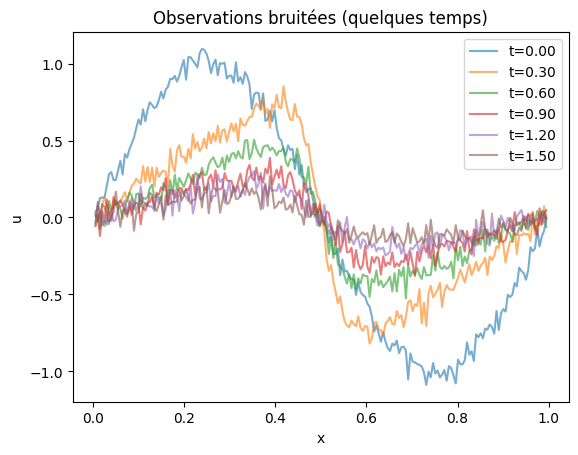

In [12]:
# Visualisation : quelques instants
plt.figure()
for k in range(0, n_steps+1, 30):
    plt.plot(x, Y_obs[k], alpha=0.6, label=f"t={k*dt:.2f}")
plt.title("Observations bruitées (quelques temps)")
plt.xlabel("x"); plt.ylabel("u")
plt.legend()
plt.show()


## 2) Prior sur \(u_0\)

On prend un prior gaussien lissant :
\[
u_0 \sim \mathcal N(m_0, C_0),\qquad Q=C_0^{-1} \approx \alpha I - \ell^2 D_{xx}
\]

- \(\alpha\) contrôle l'amplitude globale
- \(\ell\) contrôle la **longueur de corrélation** (plus grand = plus lisse)


In [5]:
def make_precision_laplacian(N, dx, alpha=1.0, ell=0.05):
    I = np.eye(N)
    Dxx = (np.diag(-2*np.ones(N)) + np.diag(np.ones(N-1), 1) + np.diag(np.ones(N-1), -1)) / (dx**2)
    return alpha * I - (ell**2) * Dxx

m0 = np.zeros(N)
Q = make_precision_laplacian(N, model.dx, alpha=1.0, ell=0.05)


## 3) Coût MAP + gradient via adjoint discret

Misfit (obs complète) :
$$
\Phi(u_0)=\frac{1}{2\sigma^2}\sum_{n=0}^T\|u_n(u_0)-y_n\|^2
$$

Adjoint (H = I) :

- $$ \lambda_T = \frac{1}{\sigma^2}(u_T-y_T) $$

- $$ \lambda_n = M_n^\top\lambda_{n+1} + \frac{1}{\sigma^2}(u_n-y_n) $$

Gradient :
$$
\nabla J(u_0)=\lambda_0 + Q(u_0-m_0)
$$


In [6]:
def cost_and_grad(model, u0, Y_obs, sigma, m0, Q):
    T = Y_obs.shape[0] - 1
    Rinv = 1.0 / (sigma**2)

    # Forward
    traj = model.evolve(u0, n_steps=T)  # (T+1, N)

    # Coût data
    mis = traj - Y_obs
    Phi = 0.5 * Rinv * np.sum(mis**2)

    # Coût prior
    du = (u0 - m0)
    prior = 0.5 * du @ (Q @ du)

    J = Phi + prior

    # Adjoint backward
    lam = Rinv * (traj[T] - Y_obs[T])  # lambda_T
    for n in range(T-1, -1, -1):
        M_n = model.get_transition_matrix(u_ref=traj[n])
        lam = M_n.T @ lam + Rinv * (traj[n] - Y_obs[n])

    grad = lam + Q @ (u0 - m0)
    return J, grad


## 4) Résolution MAP (L-BFGS-B)

On minimise \(J(u_0)\). Un bon point initial est souvent :
- zéro (si prior centré) ou
- une guess lisse (par ex. l'observation au temps 0 si disponible).


In [7]:
u0_init = np.zeros(N)

def fun(u):
    J, g = cost_and_grad(model, u, Y_obs, sigma, m0, Q)
    return J, g

res = minimize(fun, u0_init, method="L-BFGS-B", jac=True,
               options={"maxiter": 200})

u0_map = res.x
print(res.message)
print("J(u0_map) =", res.fun)


CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH
J(u0_map) = 14984.527016134816


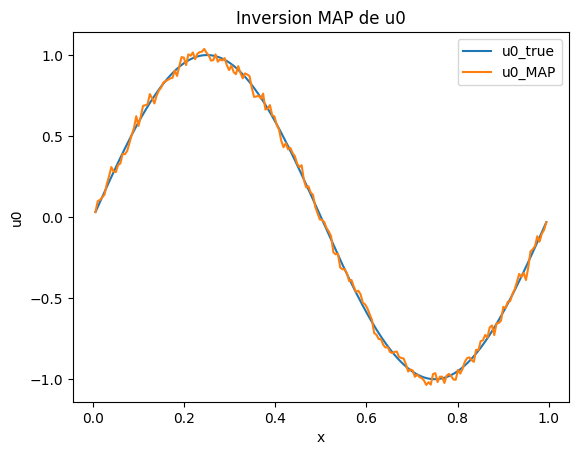

In [13]:
# Comparaison u0_true vs u0_map
plt.figure()
plt.plot(x, u0_true, label="u0_true")
plt.plot(x, u0_map, label="u0_MAP")
plt.title("Inversion MAP de u0")
plt.xlabel("x"); plt.ylabel("u0")
plt.legend()
plt.show()


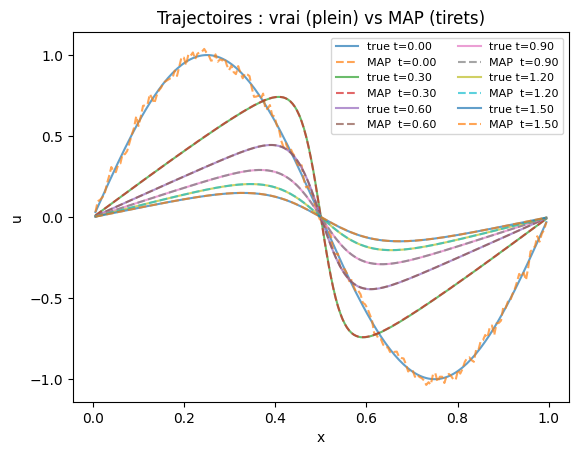

In [14]:
# Comparaison de trajectoires (vrai vs MAP) pour quelques temps
U_map = model.evolve(u0_map, n_steps=n_steps)

plt.figure()
k_list = [0, 30, 60, 90, 120, 150]
for k in k_list:
    plt.plot(x, U_true[k], alpha=0.7, label=f"true t={k*dt:.2f}")
    plt.plot(x, U_map[k], '--', alpha=0.7, label=f"MAP  t={k*dt:.2f}")
plt.title("Trajectoires : vrai (plein) vs MAP (tirets)")
plt.xlabel("x"); plt.ylabel("u")
plt.legend(ncol=2, fontsize=8)
plt.show()


## Notes pratiques

- Si l'optimisation diverge / devient instable :
  - réduire `dt`
  - augmenter `nu` (diffusivité)
  - ou réduire `n_steps` (observer plus tôt)
- L'advection centrée explicite peut générer des oscillations près des fronts raides : pour Burgers avec chocs, un schéma **conservatif/upwind** est souvent préférable.
